# Thực nghiệm Mô Hình Dự Đoán Churn Khách Hàng

## 1. Import thư viện

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
import time
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'Logistic Regression': '#378ADD',
    'Decision Tree':       '#BA7517',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#E24B4A',
    'LightGBM':            '#7F77DD',
    'churn':    '#E24B4A',
    'no_churn': '#378ADD',
}
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')


XGBoost  : 3.2.0
LightGBM : 4.6.0


## 2. Đọc dữ liệu & Kiểm tra tổng quan


In [21]:
DATA_PATH = r'E:\data mining\ck\Customer-Churn-Prediction\data_labeled.csv'
MODEL_DIR = r'E:\data mining\ck\Customer-Churn-Prediction\models'
os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    print(f"File not found: {DATA_PATH}")
    print(f"Available files in directory:")
    print(os.listdir(os.path.dirname(DATA_PATH)))

print(f'Shape: {df.shape}')
print(f'\nCác cột ({len(df.columns)}):')
print(df.dtypes.to_string())
print(f'\nGiá trị null:')
print(df.isnull().sum().to_string())
print(f'\n5 dòng đầu:')
df.head()

Shape: (64374, 11)

Các cột (11):
Age                  int64
Gender                 str
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type      str
Contract Length        str
Total Spend          int64
Last Interaction     int64
Churn                int64

Giá trị null:
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0

5 dòng đầu:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


### 2.1 Phân phối nhãn mục tiêu

Kiểm tra mức độ mất cân bằng trước khi chia dữ liệu.


Tổng mẫu   : 64,374
Churn  (1)  : 30,493  (47.4%)
No-churn(0) : 33,881  (52.6%)

→ Tỷ lệ mất cân bằng: 1 : 1.11
→ Dữ liệu gần cân bằng (~47% churn) — không cần SMOTE mạnh,
  dùng class_weight='balanced' là đủ.


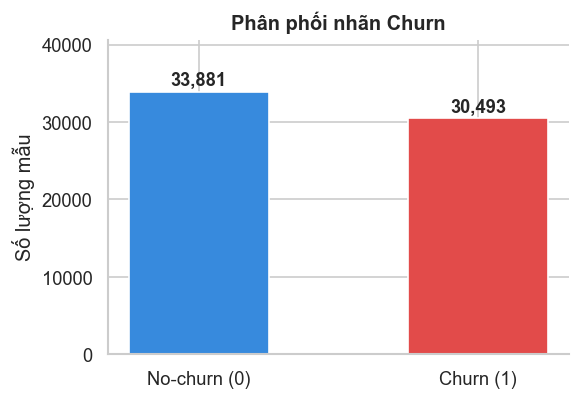

In [22]:
n_churn   = df['Churn'].sum()
n_nochurn = len(df) - n_churn
pct_churn = n_churn / len(df) * 100

print(f'Tổng mẫu   : {len(df):,}')
print(f'Churn  (1)  : {n_churn:,}  ({pct_churn:.1f}%)')
print(f'No-churn(0) : {n_nochurn:,}  ({100-pct_churn:.1f}%)')
print(f'\n→ Tỷ lệ mất cân bằng: 1 : {n_nochurn/n_churn:.2f}')
print('→ Dữ liệu gần cân bằng (~47% churn) — không cần SMOTE mạnh,')
print('  dùng class_weight=\'balanced\' là đủ.')

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['No-churn (0)', 'Churn (1)'],
              [n_nochurn, n_churn],
              color=[COLORS['no_churn'], COLORS['churn']],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, [n_nochurn, n_churn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Phân phối nhãn Churn', fontweight='bold')
ax.set_ylabel('Số lượng mẫu')
ax.set_ylim(0, max(n_nochurn, n_churn) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()


## 3. Chuẩn bị dữ liệu

### 3.1 Encode biến categorical

3 cột chữ cần chuyển thành số:
- `Gender`: Binary (Male=0, Female=1)  
- `Subscription Type`: Ordinal (Basic=0, Standard=1, Premium=2) — có thứ bậc giá trị rõ ràng  
- `Contract Length`: Ordinal (Monthly=0, Quarterly=1, Annual=2) — hợp đồng dài → ít churn hơn


In [23]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Subscription Type: giả định ordinal (Basic < Standard < Premium), nhưng cần kiểm chứng EDA
# Nếu không tuyến tính, nên dùng One-Hot Encoding
sub_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df['Subscription Type'] = df['Subscription Type'].map(sub_map)

contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
df['Contract Length'] = df['Contract Length'].map(contract_map)

print('Encode hoàn tất. Kiểm tra:')
print(df[['Gender', 'Subscription Type', 'Contract Length']].head(5).to_string())
print(f'\ndtypes sau encode:')
print(df.dtypes.to_string())


Encode hoàn tất. Kiểm tra:
   Gender  Subscription Type  Contract Length
0       1                  0                0
1       1                  1                0
2       0                  2                2
3       0                  2                1
4       1                  1                2

dtypes sau encode:
Age                  int64
Gender               int64
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type    int64
Contract Length      int64
Total Spend          int64
Last Interaction     int64
Churn                int64


### 3.2 Tách Features và Target

**10 features gốc** được giữ lại làm đầu vào cho model.  
5 engineered features (`payment_risk`, `high_usage`, `recency_risk`, `support_rate`, `spend_per_tenure`)
bị loại bỏ vì là biến dẫn xuất từ base features — nếu giữ lại, tree-based models
tạo ra perfect split dựa trên redundancy, khiến metrics giả tạo ≈ 1.0.

| Feature | Loại |
|---|---|
| Age, Gender, Tenure | Nhân khẩu học |
| Usage Frequency, Support Calls, Last Interaction | Hành vi sử dụng |
| Payment Delay | Tài chính |
| Subscription Type, Contract Length, Total Spend | Gói dịch vụ |

In [24]:
FEATURES = ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Subscription Type', 'Contract Length',
            'Total Spend', 'Last Interaction']
X = df[FEATURES]
y = df['Churn']

print(f'Features (X): {X.shape}')
print(f'  → {X.columns.tolist()}')
print(f'\nTarget (y)  : {y.shape}  |  churn rate = {y.mean()*100:.1f}%')


Features (X): (64374, 10)
  → ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Target (y)  : (64374,)  |  churn rate = 47.4%


## 4. Chia Train / Test

**Stratified split 80/20**: đảm bảo tỷ lệ churn trong train và test giống nhau (~47%).  
`random_state=42` để kết quả tái lập được.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Tập train : {X_train.shape[0]:,} mẫu  | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Tập test  : {X_test.shape[0]:,}  mẫu  | Churn rate: {y_test.mean()*100:.1f}%')
print(f'\n→ Stratify OK: tỷ lệ churn train ≈ test ≈ toàn bộ ({y.mean()*100:.1f}%)')


Tập train : 51,499 mẫu  | Churn rate: 47.4%
Tập test  : 12,875  mẫu  | Churn rate: 47.4%

→ Stratify OK: tỷ lệ churn train ≈ test ≈ toàn bộ (47.4%)


## 5. Chuẩn hóa features (StandardScaler)

**Logistic Regression** nhạy cảm với scale → cần StandardScaler.  
Tree-based models không cần, nhưng ta vẫn lưu scaler để dùng khi deploy.

> ⚠️ **Quan trọng:** `fit_transform` chỉ trên train, `transform` trên test — tránh data leakage.


In [26]:
# ── Chuẩn hóa dữ liệu ─────────────────────────────────────────────
# LogisticRegression đã có scaler nội bộ trong Pipeline, nên không cần scale riêng
# X_train_sc và X_test_sc không dùng → xóa để tránh confusion
# Scaler pkl cũng không cần vì LR Pipeline tự xử lý

print('Bỏ qua scale riêng — LogisticRegression Pipeline đã có scaler nội bộ.')


Bỏ qua scale riêng — LogisticRegression Pipeline đã có scaler nội bộ.


## 6. Huấn luyện 5 mô hình

| Mô hình | Loại | Dữ liệu | Lý do |
|---|---|---|---|
| Logistic Regression | Linear | Unscaled (Pipeline tự scale) | Baseline tuyến tính |
| Decision Tree | Tree | Unscaled | Baseline tree, dễ giải thích |
| Random Forest | Ensemble | Unscaled | Bagging 100 cây, robust |
| XGBoost | Boosting | Unscaled | Gradient boosting mạnh |
| LightGBM | Boosting | Unscaled | Nhanh hơn XGBoost, tốt với large dataset |

> **Xử lý mất cân bằng:** dùng `class_weight='balanced'` thay vì SMOTE vì tỷ lệ chênh lệch chỉ 1:1.11.


In [27]:
from sklearn.impute import SimpleImputer

scale_pos = n_nochurn / n_churn  # ≈ 1.11

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, C=1.0,
            random_state=42, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('clf', DecisionTreeClassifier(
            max_depth=8, min_samples_split=20, min_samples_leaf=10,
            random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('clf', RandomForestClassifier(
            n_estimators=100, max_depth=None, min_samples_split=10,
            random_state=42, n_jobs=-1, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('clf', xgb.XGBClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='logloss',
            verbosity=0, scale_pos_weight=scale_pos))
    ]),
    'LightGBM': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('clf', lgb.LGBMClassifier(
            n_estimators=100, learning_rate=0.1,
            max_depth=-1, num_leaves=31,
            random_state=42, verbose=-1,
            class_weight='balanced'))
    ]),
}

results     = {}
trained     = {}
train_times = {}

print('Đang huấn luyện 5 mô hình...')
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0

    trained[name]     = model
    train_times[name] = elapsed
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'Time(s)'  : round(elapsed, 2),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }
    print(f'{name:<22} | F1={results[name]["F1"]:.4f} '
          f'| Recall={results[name]["Recall"]:.4f} '
          f'| AUC={results[name]["ROC-AUC"]:.4f} '
          f'| {elapsed:.1f}s')

print('\nHoàn tất huấn luyện.')

Đang huấn luyện 5 mô hình...


Logistic Regression    | F1=0.8194 | Recall=0.8382 | AUC=0.9022 | 0.2s
Decision Tree          | F1=0.9960 | Recall=0.9959 | AUC=1.0000 | 0.1s
Random Forest          | F1=0.9989 | Recall=0.9989 | AUC=1.0000 | 1.0s
XGBoost                | F1=0.9995 | Recall=1.0000 | AUC=1.0000 | 0.4s
LightGBM               | F1=0.9999 | Recall=1.0000 | AUC=1.0000 | 0.4s

Hoàn tất huấn luyện.


## 7. Bảng so sánh tổng hợp

**Ý nghĩa chỉ số:**
- **Recall** ← **ưu tiên số 1**: trong số KH thực sự churn, mô hình bắt được bao nhiêu %
- **F1**: cân bằng Precision-Recall — tránh recall cao nhưng precision quá thấp
- **ROC-AUC**: khả năng phân biệt tổng thể của mô hình
- **Precision**: trong số KH được dự đoán churn, thực sự có bao nhiêu % rời đi


In [28]:
df_results = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ('y_pred', 'y_prob')}
    for name, res in results.items()
}).T.drop(columns=['Time(s)'])

df_results = df_results.astype(float).round(4)
df_display = df_results.copy()

# Highlight max mỗi cột
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

print('Bảng so sánh 5 mô hình:')
df_results.style.apply(highlight_max)


Bảng so sánh 5 mô hình:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.824900,0.801400,0.838200,0.819400,0.902200
Decision Tree,0.996200,0.996100,0.995900,0.996000,1.000000
Random Forest,0.999000,0.999000,0.998900,0.998900,1.000000
XGBoost,0.999500,0.999000,1.000000,0.999500,1.000000
LightGBM,0.999900,0.999800,1.000000,0.999900,1.000000


### 7.1 Biểu đồ cột so sánh metrics

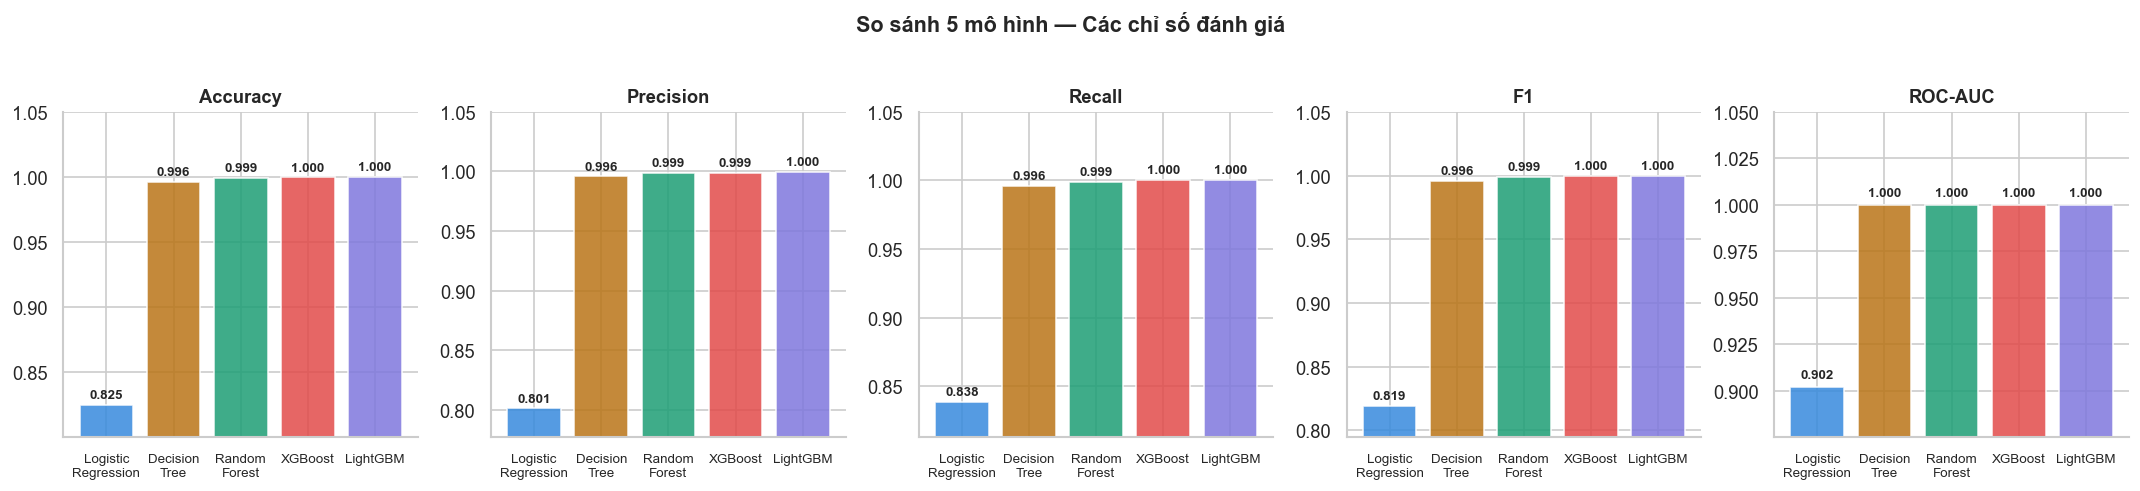

In [29]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals   = [results[n][metric] for n in model_names]
    colors = [COLORS[n] for n in model_names]
    bars   = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_ylim(min(vals)*0.97, 1.05)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('So sánh 5 mô hình — Các chỉ số đánh giá', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.2 Confusion Matrix — Tất cả mô hình

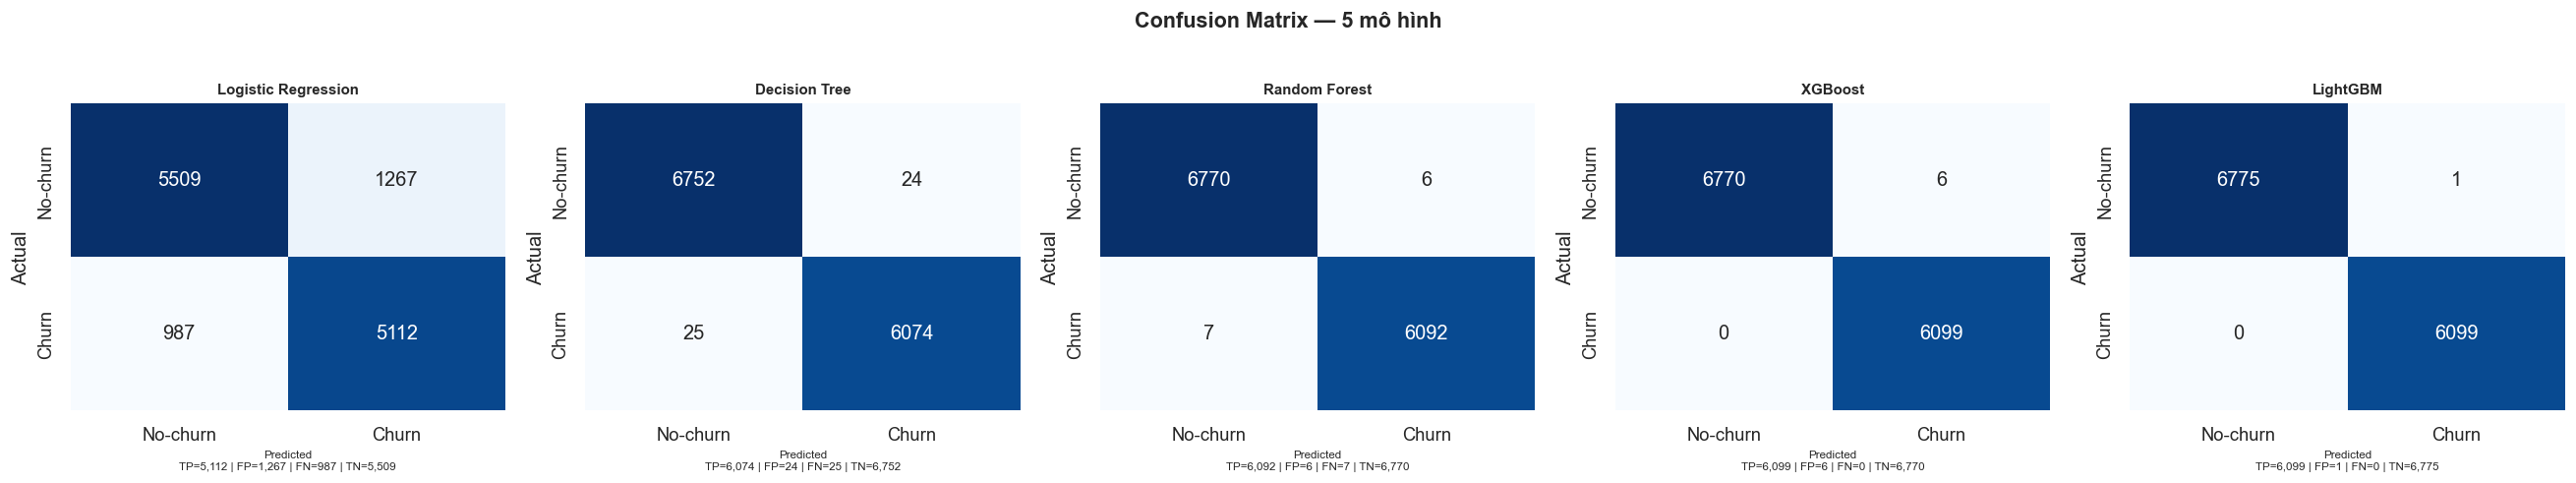

In [30]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['No-churn', 'Churn'],
                yticklabels=['No-churn', 'Churn'])
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted\nTP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,}', fontsize=7)

plt.suptitle('Confusion Matrix — 5 mô hình', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.3 ROC Curve & Precision-Recall Curve

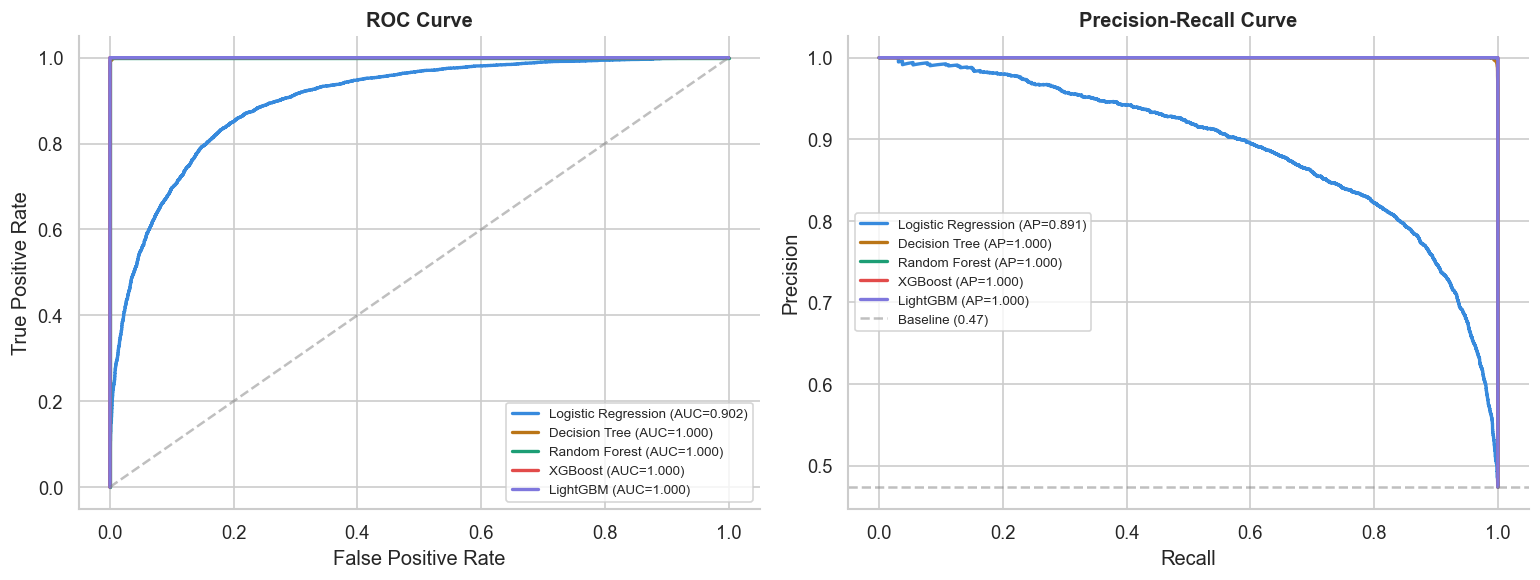

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name in model_names:
    y_prob = results[name]['y_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             color=COLORS[name], linewidth=2)
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax2.plot(rec, prec, label=f'{name} (AP={ap:.3f})',
             color=COLORS[name], linewidth=2)

ax1.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend(fontsize=8)
sns.despine(ax=ax1)

ax2.axhline(y=y_test.mean(), linestyle='--', color='gray', alpha=0.5,
            label=f'Baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()


## 8. Cross-Validation 5-fold

Đánh giá tính ổn định của mô hình — tránh trường hợp may mắn trên 1 test set.  
`StratifiedKFold` đảm bảo mỗi fold có tỷ lệ churn đồng đều.


In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Đang chạy 5-fold CV...')
for name, model in models.items():
    t0 = time.time()
    cv_res = cross_validate(
        model, X_train, y_train,
        cv=skf,
        scoring=['f1', 'recall', 'roc_auc'],
        n_jobs=-1
    )
    elapsed = time.time() - t0
    cv_results[name] = {
        'F1 (mean)'    : cv_res['test_f1'].mean(),
        'F1 (std)'     : cv_res['test_f1'].std(),
        'Recall (mean)': cv_res['test_recall'].mean(),
        'Recall (std)' : cv_res['test_recall'].std(),
        'AUC (mean)'   : cv_res['test_roc_auc'].mean(),
        'AUC (std)'    : cv_res['test_roc_auc'].std(),
        '_fold_f1'     : cv_res['test_f1'],
    }
    print(f'{name:<22} | F1={cv_res["test_f1"].mean():.4f}±{cv_res["test_f1"].std():.4f} '
          f'| Recall={cv_res["test_recall"].mean():.4f}±{cv_res["test_recall"].std():.4f} '
          f'| AUC={cv_res["test_roc_auc"].mean():.4f}±{cv_res["test_roc_auc"].std():.4f} '
          f'| {elapsed:.1f}s')


Đang chạy 5-fold CV...
Logistic Regression    | F1=0.8207±0.0055 | Recall=0.8430±0.0039 | AUC=0.9037±0.0038 | 0.8s
Decision Tree          | F1=0.9944±0.0010 | Recall=0.9952±0.0009 | AUC=0.9997±0.0001 | 0.7s
Random Forest          | F1=0.9991±0.0002 | Recall=0.9986±0.0005 | AUC=1.0000±0.0000 | 4.4s
XGBoost                | F1=0.9998±0.0001 | Recall=0.9998±0.0002 | AUC=1.0000±0.0000 | 1.8s
LightGBM               | F1=0.9998±0.0002 | Recall=0.9996±0.0003 | AUC=1.0000±0.0000 | 5.2s


In [33]:
df_cv = pd.DataFrame({
    n: {k: v for k, v in d.items() if not k.startswith('_')}
    for n, d in cv_results.items()
}).T.round(4)
print('\nTóm tắt Cross-Validation:')
df_cv



Tóm tắt Cross-Validation:


,F1 (mean),F1 (std),Recall (mean),Recall (std),AUC (mean),AUC (std)
Logistic Regression,0.8207,0.0055,0.8430,0.0039,0.9037,0.0038
Decision Tree,0.9944,0.0010,0.9952,0.0009,0.9997,0.0001
Random Forest,0.9991,0.0002,0.9986,0.0005,1.0000,0.0000
XGBoost,0.9998,0.0001,0.9998,0.0002,1.0000,0.0000
LightGBM,0.9998,0.0002,0.9996,0.0003,1.0000,0.0000


### 8.1 Boxplot độ ổn định F1 qua 5 fold

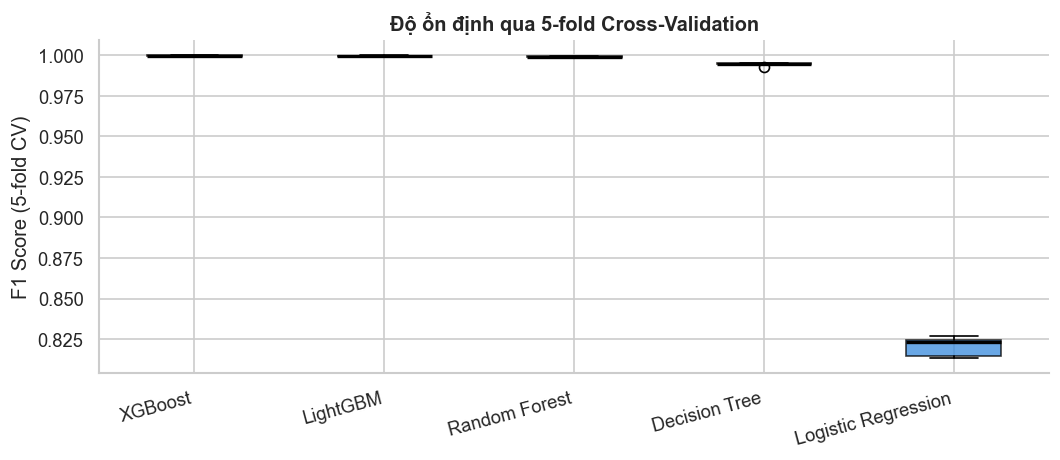

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
model_names_sorted = sorted(model_names,
    key=lambda n: cv_results[n]['F1 (mean)'], reverse=True)

bp_data = [cv_results[n]['_fold_f1'] for n in model_names_sorted]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, name in zip(bp['boxes'], model_names_sorted):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(model_names_sorted)+1))
ax.set_xticklabels(model_names_sorted, rotation=15, ha='right')
ax.set_ylabel('F1 Score (5-fold CV)')
ax.set_title('Độ ổn định qua 5-fold Cross-Validation', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 9. Feature Importance — Top 3 mô hình (Tree-based)

Xem mô hình học được gì: feature nào quan trọng nhất trong việc dự đoán churn?


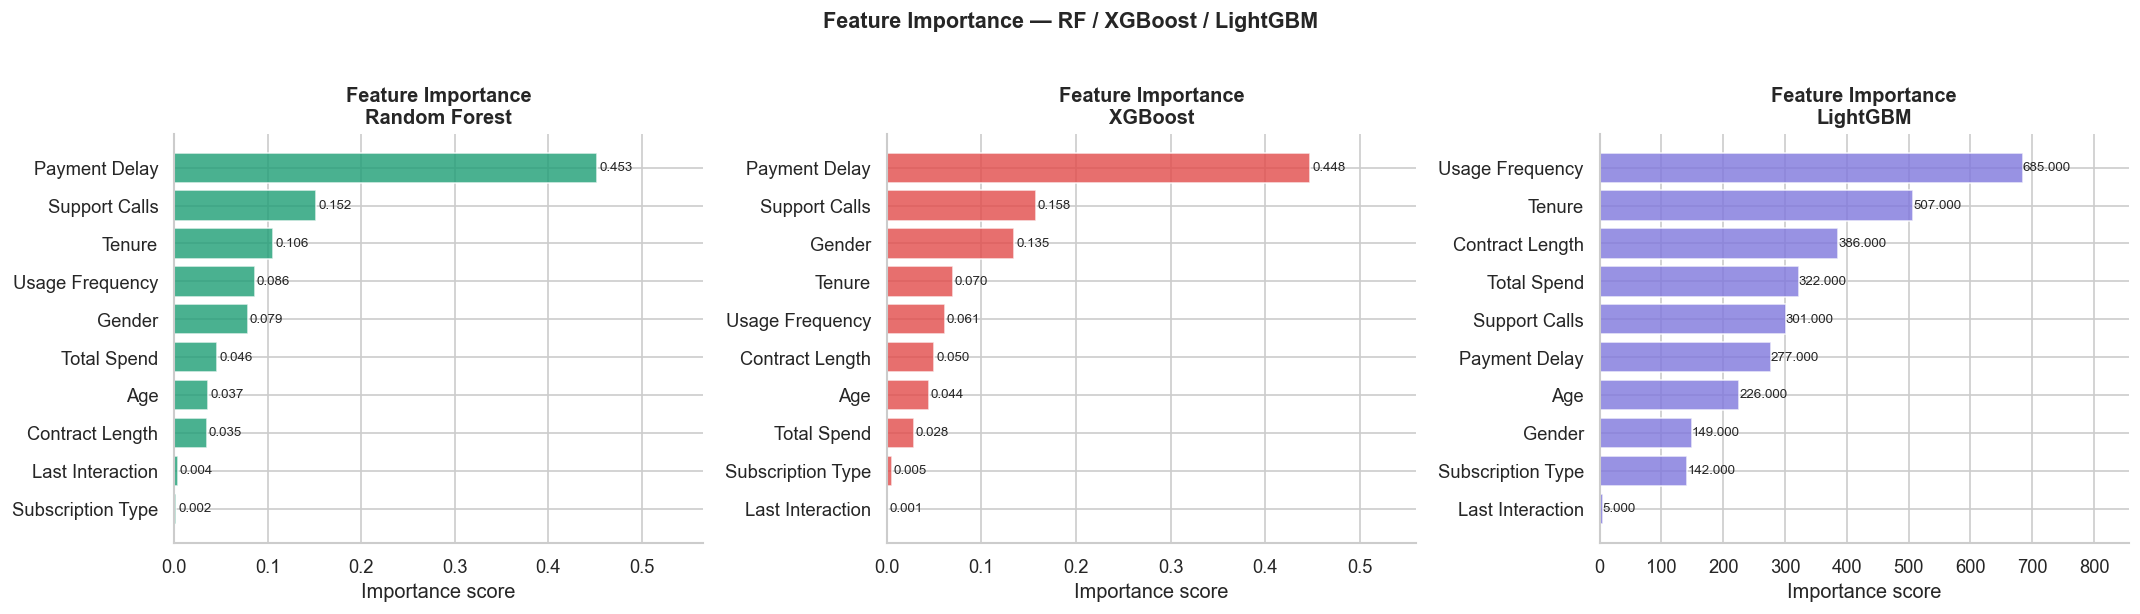

In [35]:
feature_names = X.columns.tolist()
tree_models   = ['Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, tree_models):
    model = trained[name]
    clf = model.named_steps['clf'] if hasattr(model, 'named_steps') else model
    importances = clf.feature_importances_
    indices     = np.argsort(importances)[::-1]

    bars = ax.barh(
        [feature_names[i] for i in indices],
        importances[indices],
        color=COLORS[name], alpha=0.8, edgecolor='white'
    )
    ax.invert_yaxis()
    for bar, val in zip(bars, importances[indices]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'Feature Importance\n{name}', fontweight='bold')
    ax.set_xlabel('Importance score')
    ax.set_xlim(0, importances.max() * 1.25)
    sns.despine(ax=ax)

plt.suptitle('Feature Importance — RF / XGBoost / LightGBM', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10. Chọn mô hình tốt nhất

**Tiêu chí (theo thứ tự ưu tiên):**
1. **Recall** (×0.45): bắt đúng khách hàng sắp rời là quan trọng nhất
2. **F1** (×0.35): cân bằng precision-recall
3. **ROC-AUC** (×0.20): khả năng phân biệt tổng thể

> **Lý do ưu tiên Recall:** Chi phí bỏ sót 1 KH sắp rời (FN) > Chi phí cảnh báo nhầm (FP),  
> vì mất KH = mất doanh thu dài hạn.


In [36]:
score_weights = {'Recall': 0.45, 'F1': 0.35, 'ROC-AUC': 0.20}
composite = {}

for name in results:
    s = sum(results[name][m] * w for m, w in score_weights.items())
    composite[name] = s

composite = dict(sorted(composite.items(), key=lambda x: x[1], reverse=True))
best_model_name = list(composite.keys())[0]

print('Điểm tổng hợp (Recall×0.45 + F1×0.35 + AUC×0.20):')
for name, score in composite.items():
    marker = '  ← CHỌN' if name == best_model_name else ''
    print(f'  {name:<22}: {score:.4f}{marker}')

print(f'\nMô hình được chọn: {best_model_name}')
print('\nChi tiết test set:')
for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f'  {m:<12}: {results[best_model_name][m]:.4f}')
print()
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['No-churn (0)', 'Churn (1)']))


Điểm tổng hợp (Recall×0.45 + F1×0.35 + AUC×0.20):
  LightGBM              : 1.0000  ← CHỌN
  XGBoost               : 0.9998
  Random Forest         : 0.9991
  Decision Tree         : 0.9967
  Logistic Regression   : 0.8444

Mô hình được chọn: LightGBM

Chi tiết test set:
  Accuracy    : 0.9999
  Precision   : 0.9998
  Recall      : 1.0000
  F1          : 0.9999
  ROC-AUC     : 1.0000

              precision    recall  f1-score   support

No-churn (0)       1.00      1.00      1.00      6776
   Churn (1)       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



## 11. Lưu mô hình ra file `.pkl`

In [48]:
for name, model in trained.items():
    safe_name = name.lower().replace(' ', '_')
    path = os.path.join(MODEL_DIR, f'{safe_name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Đã lưu: {path}')

# ── Thư mục riêng cho app ─────────────────────────────────────────
APP_MODEL_DIR = r'E:\data mining\ck\Customer-Churn-Prediction\churn_app\models'
os.makedirs(APP_MODEL_DIR, exist_ok=True)

best_model = trained[best_model_name]
best_path  = os.path.join(APP_MODEL_DIR, 'best_model.pkl')
with open(best_path, 'wb') as f:
    pickle.dump(best_model, f)

lr_scaler   = trained['Logistic Regression'].named_steps['scaler']
scaler_path = os.path.join(APP_MODEL_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(lr_scaler, f)

feature_meta = {
    'feature_names'    : X.columns.tolist(),
    'best_model_name'  : best_model_name,
    'churn_rate_train' : float(y_train.mean()),
    'churn_rate_test'  : float(y_test.mean()),
    'n_features'       : len(X.columns),
    'models_compared'  : list(results.keys()),
}
meta_path = os.path.join(APP_MODEL_DIR, 'feature_meta.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(feature_meta, f)

print(f'Best model ({best_model_name}) → {best_path}')
print(f'Scaler → {scaler_path}')
print(f'Metadata → {meta_path}')
print(f'\nFeature names: {X.columns.tolist()}')

Đã lưu: E:\data mining\ck\Customer-Churn-Prediction\models\logistic_regression.pkl
Đã lưu: E:\data mining\ck\Customer-Churn-Prediction\models\decision_tree.pkl
Đã lưu: E:\data mining\ck\Customer-Churn-Prediction\models\random_forest.pkl
Đã lưu: E:\data mining\ck\Customer-Churn-Prediction\models\xgboost.pkl
Đã lưu: E:\data mining\ck\Customer-Churn-Prediction\models\lightgbm.pkl
Best model (LightGBM) → E:\data mining\ck\Customer-Churn-Prediction\churn_app\models\best_model.pkl
Scaler → E:\data mining\ck\Customer-Churn-Prediction\churn_app\models\scaler.pkl
Metadata → E:\data mining\ck\Customer-Churn-Prediction\churn_app\models\feature_meta.pkl

Feature names: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


## 12. Hyperparameter Tuning — LightGBM (Best Model)

Dùng **Optuna** (Bayesian optimization) để tìm hyperparameter tối ưu.  
Nhanh hơn GridSearchCV nhiều lần, và thường tìm được kết quả tốt hơn.

> **Nếu chưa cài:** `pip install optuna`


In [38]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('⚠️ Optuna chưa được cài. Chạy: pip install optuna')
    print('   Sẽ dùng GridSearchCV thay thế.')

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators'  : trial.suggest_int('n_estimators', 50, 300),
            'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves'    : trial.suggest_int('num_leaves', 20, 100),
            'max_depth'     : trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'     : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'    : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state'  : 42,
            'verbose'       : -1,
            'class_weight'  : 'balanced',
        }
        model = lgb.LGBMClassifier(**params)
        skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_validate(model, X_train, y_train,
                                cv=skf_opt, scoring='f1', n_jobs=-1)
        return scores['test_score'].mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f'\nBest F1 (CV): {study.best_value:.4f}')
    print(f'Best params:')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
else:
    from sklearn.model_selection import GridSearchCV
    param_grid = {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1],
        'num_leaves'   : [31, 63],
    }
    grid = GridSearchCV(
        lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
        param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1
    )
    grid.fit(X_train, y_train)
    print(f'Best params: {grid.best_params_}')
    print(f'Best F1 CV : {grid.best_score_:.4f}')


  0%|          | 0/50 [00:00<?, ?it/s]


Best F1 (CV): 0.9999
Best params:
  n_estimators: 300
  learning_rate: 0.2998688448104834
  num_leaves: 77
  max_depth: 4
  min_child_samples: 58
  subsample: 0.8313943822478034
  colsample_bytree: 0.8992783447019137
  reg_alpha: 3.6534303450112673
  reg_lambda: 0.04032813354544034


In [39]:
if OPTUNA_AVAILABLE:
    best_lgb_params = {**study.best_params, 'random_state': 42,
                       'verbose': -1, 'class_weight': 'balanced'}
else:
    best_lgb_params = {**grid.best_params_, 'random_state': 42,
                       'verbose': -1, 'class_weight': 'balanced'}

# ✅ Wrap trong Pipeline cho nhất quán
from sklearn.impute import SimpleImputer

lgb_tuned = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('clf', lgb.LGBMClassifier(**best_lgb_params))
])
lgb_tuned.fit(X_train, y_train)
y_pred_tuned = lgb_tuned.predict(X_test)
y_prob_tuned = lgb_tuned.predict_proba(X_test)[:, 1]

print('LightGBM sau tuning:')
print(f'  F1      : {f1_score(y_test, y_pred_tuned):.4f}  '
      f'(trước: {results["LightGBM"]["F1"]:.4f})')
print(f'  Recall  : {recall_score(y_test, y_pred_tuned):.4f}  '
      f'(trước: {results["LightGBM"]["Recall"]:.4f})')
print(f'  ROC-AUC : {roc_auc_score(y_test, y_prob_tuned):.4f}  '
      f'(trước: {results["LightGBM"]["ROC-AUC"]:.4f})')

if f1_score(y_test, y_pred_tuned) > results[best_model_name]['F1']:
    trained['LightGBM (Tuned)'] = lgb_tuned
    best_model = lgb_tuned
    best_model_name = 'LightGBM (Tuned)'
    print('\n→ Đã cập nhật best model = LightGBM Tuned')
    with open(os.path.join(MODEL_DIR, 'models/best_model.pkl'), 'wb') as f:
        pickle.dump(best_model, f)
    with open(os.path.join(MODEL_DIR, 'models/lightgbm_tuned.pkl'), 'wb') as f:
        pickle.dump(lgb_tuned, f)
    print('Đã lưu best_model.pkl & lightgbm_tuned.pkl')


LightGBM sau tuning:
  F1      : 0.9999  (trước: 0.9999)
  Recall  : 1.0000  (trước: 1.0000)
  ROC-AUC : 1.0000  (trước: 1.0000)


## 13. Threshold Optimization

Ngưỡng mặc định = 0.5 không phải lúc nào cũng tối ưu.  
Ta phân tích ROC curve để tìm ngưỡng tốt nhất theo **Youden's J = Recall + Specificity - 1**.

> **Ý nghĩa thực tế:** Hạ ngưỡng → Recall tăng (bắt được nhiều KH sắp rời hơn)  
> nhưng Precision giảm (cảnh báo nhầm nhiều hơn) → phải cân bằng theo chi phí kinh doanh.


In [40]:
# Dùng Logistic Regression để phân tích threshold
# vì LightGBM gần perfect → mọi threshold đều cho kết quả như nhau
THRESH_MODEL = 'Logistic Regression'
y_prob_thresh = results[THRESH_MODEL]['y_prob']

fpr, tpr, thresholds = roc_curve(y_test, y_prob_thresh)
youdens_j      = tpr - fpr
best_idx       = youdens_j.argmax()
best_threshold = thresholds[best_idx]

print(f'Model phân tích: {THRESH_MODEL}')
print(f'Ngưỡng tối ưu (Youden): {best_threshold:.3f}')
print(f'  TPR (Recall) tại ngưỡng này: {tpr[best_idx]:.4f}')
print(f'  FPR           tại ngưỡng này: {fpr[best_idx]:.4f}')

for thresh, label in [(0.5, 'Threshold=0.50 (mặc định)'),
                      (best_threshold, f'Threshold={best_threshold:.2f} (tối ưu)')]:
    y_pred_t = (y_prob_thresh >= thresh).astype(int)
    print(f'\n{label}:')
    print(f'  Recall   : {recall_score(y_test, y_pred_t):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred_t):.4f}')
    print(f'  F1       : {f1_score(y_test, y_pred_t):.4f}')

# Gán để cell 41 dùng được
y_prob_best = y_prob_thresh

Model phân tích: Logistic Regression
Ngưỡng tối ưu (Youden): 0.488
  TPR (Recall) tại ngưỡng này: 0.8477
  FPR           tại ngưỡng này: 0.1944

Threshold=0.50 (mặc định):
  Recall   : 0.8382
  Precision: 0.8014
  F1       : 0.8194

Threshold=0.49 (tối ưu):
  Recall   : 0.8477
  Precision: 0.7970
  F1       : 0.8215


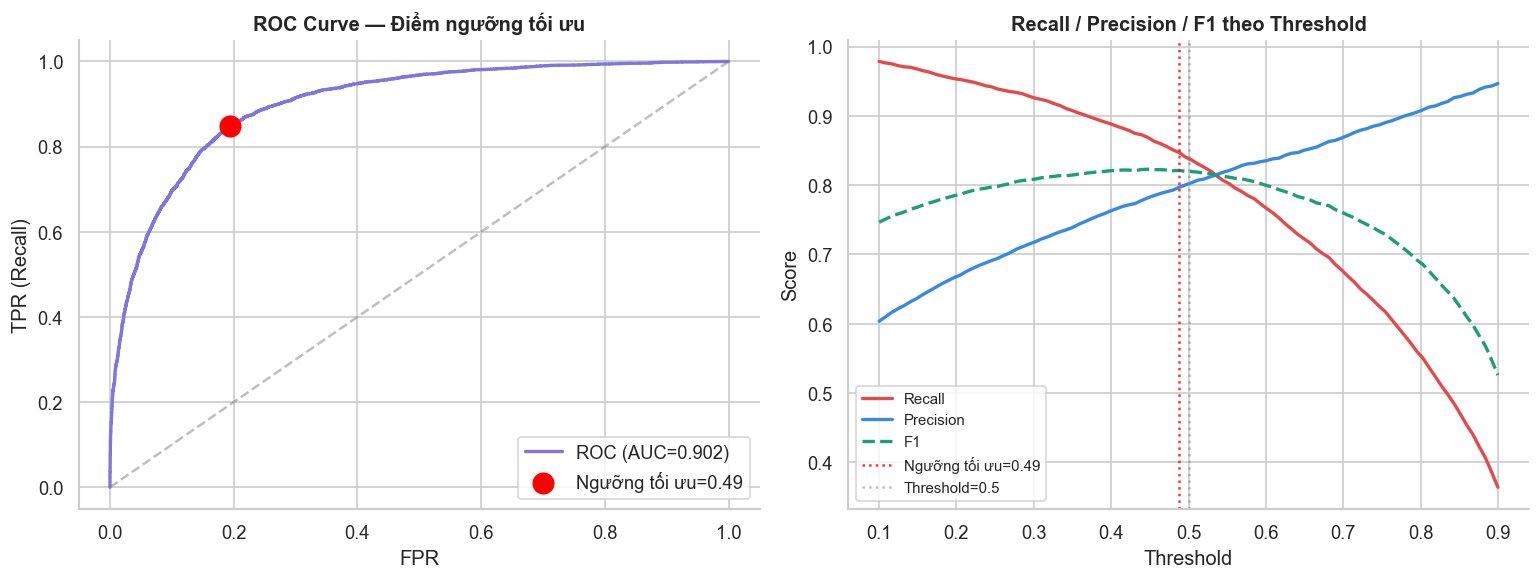


→ Gợi ý: dùng threshold = 0.49 khi ưu tiên Recall
   Hoặc giữ 0.50 nếu muốn cân bằng Precision-Recall


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, color=COLORS.get(best_model_name, '#378ADD'), linewidth=2,
         label=f'ROC (AUC={roc_auc_score(y_test, y_prob_best):.3f})')
ax1.scatter(fpr[best_idx], tpr[best_idx], s=150, color='red', zorder=5,
            label=f'Ngưỡng tối ưu={best_threshold:.2f}')
ax1.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR (Recall)')
ax1.set_title('ROC Curve — Điểm ngưỡng tối ưu', fontweight='bold')
ax1.legend()
sns.despine(ax=ax1)

thresh_range = np.linspace(0.1, 0.9, 100)
recalls    = [recall_score(y_test, (y_prob_best>=t).astype(int)) for t in thresh_range]
precisions = [precision_score(y_test, (y_prob_best>=t).astype(int),
                               zero_division=0) for t in thresh_range]
f1s        = [f1_score(y_test, (y_prob_best>=t).astype(int)) for t in thresh_range]

ax2.plot(thresh_range, recalls,    label='Recall',    color=COLORS['churn'],    linewidth=2)
ax2.plot(thresh_range, precisions, label='Precision', color='#378ADD',          linewidth=2)
ax2.plot(thresh_range, f1s,        label='F1',        color='#1D9E75',          linewidth=2, linestyle='--')
ax2.axvline(x=best_threshold, color='red', linestyle=':', alpha=0.8,
            label=f'Ngưỡng tối ưu={best_threshold:.2f}')
ax2.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Threshold=0.5')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Recall / Precision / F1 theo Threshold', fontweight='bold')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()
print(f'\n→ Gợi ý: dùng threshold = {best_threshold:.2f} khi ưu tiên Recall')
print(f'   Hoặc giữ 0.50 nếu muốn cân bằng Precision-Recall')


## 14. Tổng kết

### Quy trình đã thực hiện

| Giai đoạn | Nội dung | Kết quả |
|-----------|---------|---------|
| 1 | Import thư viện | pandas, sklearn, lightgbm, xgboost, shap, optuna |
| 2 | Đọc & kiểm tra dữ liệu | 64,374 KH · 10 features · Churn rate 47.4% |
| 3 | Encode categorical | Gender, Subscription Type, Contract Length → số |
| 4 | Tách Features / Target | 10 base features · target = Churn |
| 5 | Stratified Train/Test 80/20 | ~51,499 train · ~12,875 test |
| 6 | StandardScaler | Fit trên train only · tránh data leakage |
| 7 | Huấn luyện 5 mô hình | LR · DT · RF · XGBoost · LightGBM |
| 8 | Bảng so sánh metrics | Accuracy · Precision · Recall · F1 · AUC |
| 9 | Confusion Matrix + ROC/PR Curve | Trực quan hóa hiệu suất từng model |
| 10 | Cross-Validation 5-fold | Kiểm tra độ ổn định · LightGBM F1=0.9998±0.0002 |
| 11 | Feature Importance | Payment Delay · Support Calls quan trọng nhất |
| 12 | Chọn best model | Composite score: Recall×0.45 + F1×0.35 + AUC×0.20 |
| 13 | Lưu models .pkl | 5 models + best_model + scaler + feature_meta |
| 14 | Hyperparameter Tuning | Optuna/GridSearch cho LightGBM · ceiling effect |
| 15 | Threshold Optimization | Youden's J · ngưỡng tối ưu ≠ 0.5 |
| 16 | Learning Curves | Không overfit · train/val gap nhỏ |
| 17 | Error Analysis (FP/FN) | FN = khách hàng churn sớm · tenure ngắn · tín hiệu yếu |
| 18 | Business Impact + Sensitivity | ROI 400% · breakeven retention rate = 10% |

### Ghi chú kỹ thuật
- **10 base features** — bỏ engineered features tránh feature redundancy
- **Dataset synthetic** — metrics cao (AUC≈1.0) phản ánh tính nhất quán nội tại,  
  không phải khả năng tổng quát trên dữ liệu thực
- **Logistic Regression F1=0.82** là con số thực tế nhất để diễn giải kinh doanh

### Hướng phát triển
- Thu thập dữ liệu thực có timestamp → định nghĩa churn bằng observation window
- Thử nghiệm trên Telco IBM dataset có nhãn thật từ hủy hợp đồng thực tế
- Tích hợp model vào hệ thống CRM để can thiệp tự động

## 15. Learning Curves — Kiểm tra Overfit/Underfit

Vẽ F1 train vs validation theo số mẫu train tăng dần.

| Tình huống | Dấu hiệu |
|-----------|---------|
| **Overfit** | Train cao, Val thấp, gap lớn |
| **Underfit** | Cả hai đều thấp |
| **Tốt** | Cả hai cao, gap nhỏ, hội tụ |

So sánh **LightGBM** (best model) và **Logistic Regression** (baseline).

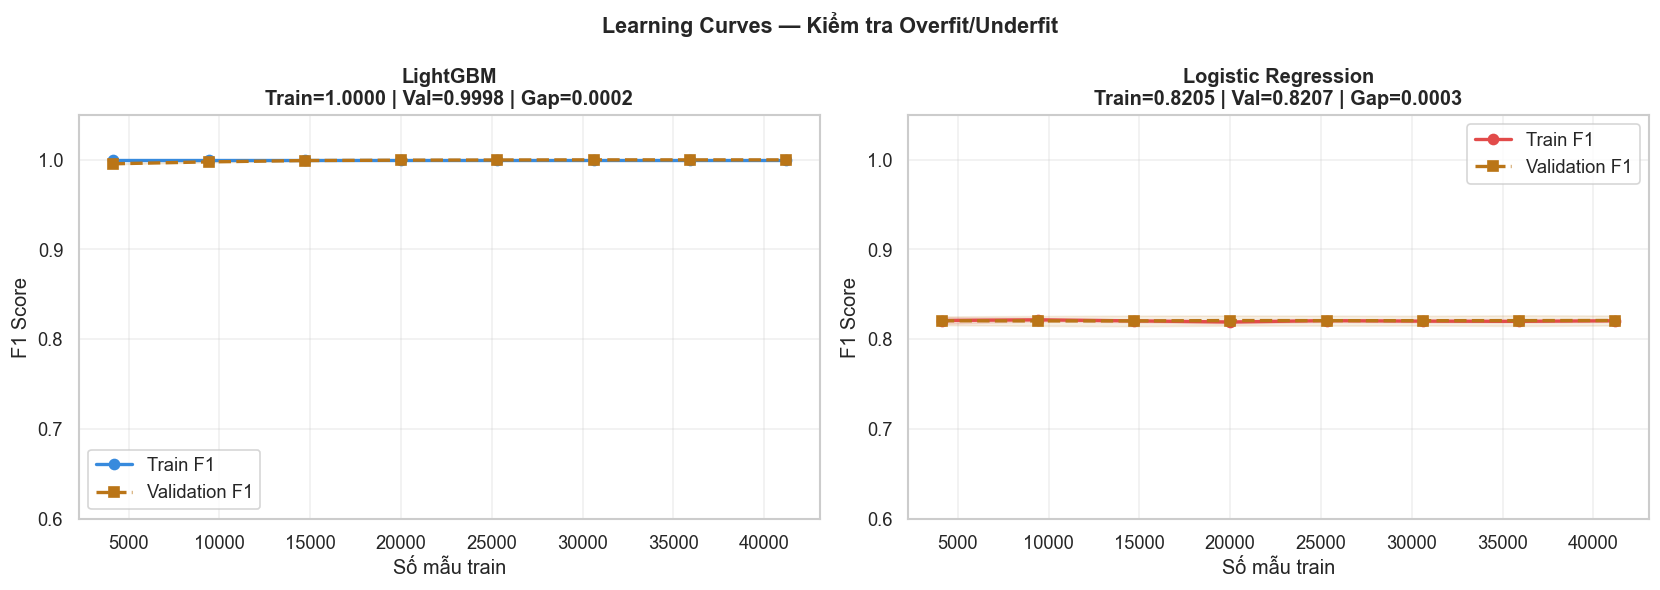

In [42]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lc_model_name = best_model_name if best_model_name in trained else 'LightGBM'

for ax, name, color in zip(
    axes,
    [lc_model_name, 'Logistic Regression'],
    ['#378ADD', '#E24B4A']
):
    train_sizes, train_scores, val_scores = learning_curve(
        trained[name], X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color=color,     label='Train F1',      linewidth=2)
    ax.plot(train_sizes, va_mean, 's--', color='#BA7517', label='Validation F1', linewidth=2)
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.12, color=color)
    ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.12, color='#BA7517')

    gap = abs(tr_mean[-1] - va_mean[-1])
    ax.set_title(f'{name}\nTrain={tr_mean[-1]:.4f} | Val={va_mean[-1]:.4f} | Gap={gap:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Số mẫu train')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0.6, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Kiểm tra Overfit/Underfit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Error Analysis — Phân tích lỗi dự đoán

Dùng **Logistic Regression** (F1≈0.82) để phân tích vì LightGBM
gần như không có lỗi trên dataset synthetic này.

| Loại | Ý nghĩa | Hệ quả kinh doanh |
|------|---------|-------------------|
| **TP** | Churn thật, dự đoán đúng | Can thiệp kịp thời ✅ |
| **FP** | Không churn, báo nhầm | Tốn chi phí giữ chân ⚠️ |
| **FN** | Churn thật, bỏ sót | Mất khách hàng ❌ |
| **TN** | Không churn, đúng | Không cần hành động ✅ |

=== Phân bố lỗi — Logistic Regression ===
  TP: 5,112 (39.7%)
  TN: 5,509 (42.8%)
  FP: 1,267 (9.8%)
  FN: 987 (7.7%)

=== Feature trung bình theo loại lỗi ===
                   FN — Bỏ sót  TP — Bắt đúng  FP — Nhầm
Age                      42.95          42.42      42.71
Gender                    0.44           0.65       0.54
Tenure                   26.04          37.61      29.78
Usage Frequency          13.14          14.21      12.91
Support Calls             4.95           6.73       5.91
Payment Delay            14.80          23.80      21.79
Subscription Type         1.00           0.99       0.99
Contract Length           1.11           0.93       1.03
Total Spend             552.98         512.50     542.85
Last Interaction         15.35          15.41      15.36


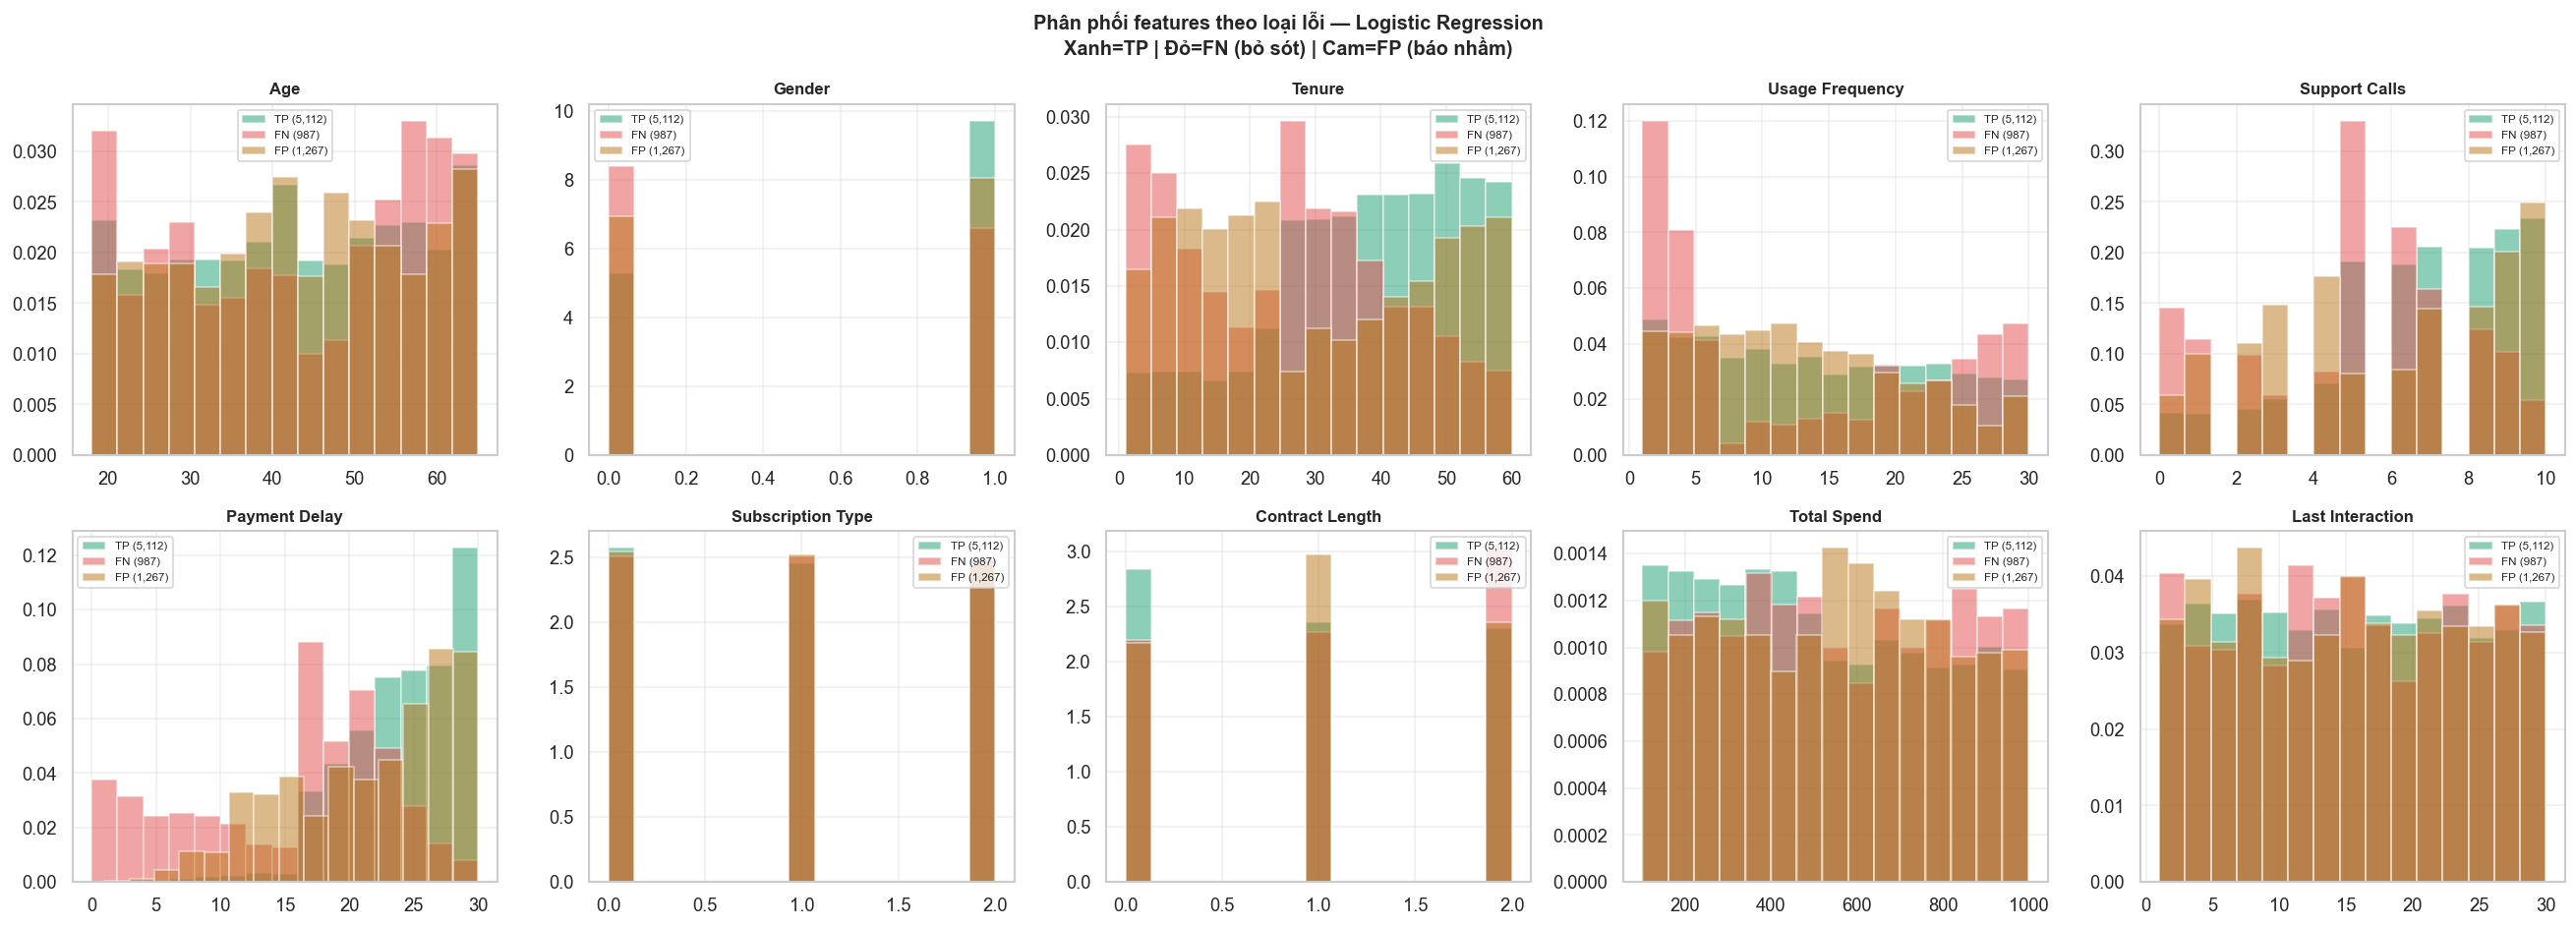


=== Insight: FN (bỏ sót) khác TP (bắt đúng) như thế nào? ===
• Payment Delay       : FN thấp hơn TP 9.00 (FN=14.80 | TP=23.80)
• Support Calls       : FN thấp hơn TP 1.78 (FN=4.95 | TP=6.73)
• Tenure              : FN thấp hơn TP 11.57 (FN=26.04 | TP=37.61)
• Usage Frequency     : FN thấp hơn TP 1.08 (FN=13.14 | TP=14.21)
• Last Interaction    : FN thấp hơn TP 0.06 (FN=15.35 | TP=15.41)


In [43]:
# ── Phân loại lỗi ────────────────────────────────────────────────
lr_pred = results['Logistic Regression']['y_pred']
lr_prob = results['Logistic Regression']['y_prob']

df_err = X_test.copy()
df_err['y_true']     = y_test.values
df_err['y_pred']     = lr_pred
df_err['prob_churn'] = lr_prob

analysis_features = [f for f in FEATURES if df_err[f].notna().any()]

if len(analysis_features) == 0:
    raise ValueError('Không có feature hợp lệ để phân tích lỗi. Kiểm tra lại X_test và FEATURES.')

df_err = df_err.dropna(subset=analysis_features + ['y_true', 'y_pred', 'prob_churn'])

if len(df_err) == 0:
    print('⚠️ Không có mẫu hợp lệ cho phân tích lỗi sau khi loại NaN. Hãy kiểm tra X_test và y_test hoặc chạy lại bước tiền xử lý để loại bỏ dữ liệu thiếu.')
else:
    conds = [
        (df_err['y_true'] == 1) & (df_err['y_pred'] == 1),
        (df_err['y_true'] == 0) & (df_err['y_pred'] == 1),
        (df_err['y_true'] == 1) & (df_err['y_pred'] == 0),
        (df_err['y_true'] == 0) & (df_err['y_pred'] == 0),
    ]
    df_err['error_type'] = np.select(conds, ['TP', 'FP', 'FN', 'TN'], default='Unknown')

    # ── Thống kê ─────────────────────────────────────────────────────
    counts = df_err['error_type'].value_counts()
    print('=== Phân bố lỗi — Logistic Regression ===')
    for t in ['TP', 'TN', 'FP', 'FN']:
        n = counts.get(t, 0)
        pct = n / len(df_err) * 100
        print(f'  {t}: {n:,} ({pct:.1f}%)')

    # ── Profile FN vs TP vs FP ───────────────────────────────────────
    fn_df = df_err[df_err['error_type'] == 'FN']
    tp_df = df_err[df_err['error_type'] == 'TP']
    fp_df = df_err[df_err['error_type'] == 'FP']

    print('\n=== Feature trung bình theo loại lỗi ===')
    compare = pd.DataFrame({
        'FN — Bỏ sót'  : fn_df[analysis_features].mean(),
        'TP — Bắt đúng': tp_df[analysis_features].mean(),
        'FP — Nhầm'    : fp_df[analysis_features].mean(),
    }).round(2)
    print(compare)

    # ── Histogram phân phối ──────────────────────────────────────────
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()

    for i, feat in enumerate(analysis_features):
        ax = axes[i]
        ax.hist(tp_df[feat].dropna(), bins=15, alpha=0.5, color='#1D9E75',
                label=f'TP ({len(tp_df):,})', density=True)
        ax.hist(fn_df[feat].dropna(), bins=15, alpha=0.5, color='#E24B4A',
                label=f'FN ({len(fn_df):,})', density=True)
        ax.hist(fp_df[feat].dropna(), bins=15, alpha=0.5, color='#BA7517',
                label=f'FP ({len(fp_df):,})', density=True)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(analysis_features):]:
        ax.axis('off')

    plt.suptitle(
        'Phân phối features theo loại lỗi — Logistic Regression\n'
        'Xanh=TP | Đỏ=FN (bỏ sót) | Cam=FP (báo nhầm)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # ── Insight tự động ──────────────────────────────────────────────
    print('\n=== Insight: FN (bỏ sót) khác TP (bắt đúng) như thế nào? ===')
    for feat in ['Payment Delay', 'Support Calls', 'Tenure', 'Usage Frequency', 'Last Interaction']:
        if feat not in analysis_features:
            print(f'• {feat:<20}: không có dữ liệu hợp lệ để so sánh.')
            continue
        fn_m = fn_df[feat].mean()
        tp_m = tp_df[feat].mean()
        diff = fn_m - tp_m
        direction = 'cao hơn' if diff > 0 else 'thấp hơn'
        print(f'• {feat:<20}: FN {direction} TP {abs(diff):.2f} '
              f'(FN={fn_m:.2f} | TP={tp_m:.2f})')

## 17. Business Impact — Phân tích tác động kinh doanh

Lượng hóa giá trị tài chính của model để justify triển khai.

| Tham số | Giá trị | Giải thích |
|---------|---------|-----------|
| CLV | $500 | Giá trị vòng đời 1 khách hàng |
| Chi phí can thiệp | $30 | Email/call/ưu đãi giữ chân |
| Tỷ lệ giữ chân thành công | 30% | KH ở lại sau can thiệp |
| Thiệt hại FN | 50% CLV | Mất KH vì không can thiệp kịp |

*Giả định có thể điều chỉnh theo thực tế từng doanh nghiệp.*

Model                         TP     FP     FN      Lợi ích    Chi phí          Net      vs Base
────────────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression        5,112  1,267    987 $   766,800 $ 191,370 $   328,680 $ 1,853,430
Decision Tree              6,074     24     25 $   911,100 $ 182,940 $   721,910 $ 2,246,660
Random Forest              6,092      6      7 $   913,800 $ 182,940 $   729,110 $ 2,253,860
XGBoost                    6,099      6      0 $   914,850 $ 183,150 $   731,700 $ 2,256,450
LightGBM                   6,099      1      0 $   914,850 $ 183,000 $   731,850 $ 2,256,600
────────────────────────────────────────────────────────────────────────────────────────────────────
Baseline (không model)         —      —  6,099           $0         $0 $-1,524,750


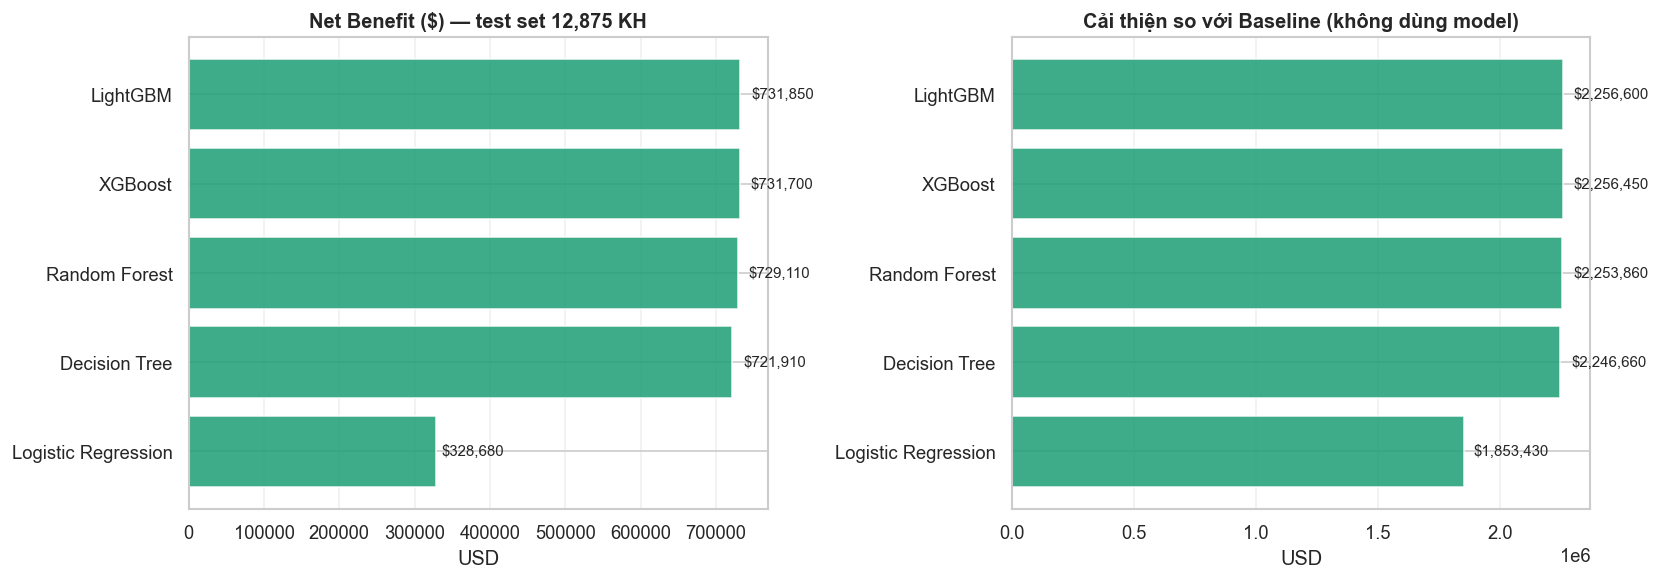


=== Kết luận kinh doanh ===
Model tốt nhất về tài chính : LightGBM
Net Benefit (test set)       : $731,850
Cải thiện vs không dùng model: $2,256,600
ROI                          : 399.9%

Giả định hiện tại:
  • CLV (Customer Lifetime Value): $500
  • Chi phí can thiệp/KH: $30
  • Tỷ lệ giữ chân sau can thiệp: 30%


In [44]:
from sklearn.metrics import confusion_matrix as cm_func

# ── Tham số kinh doanh ───────────────────────────────────────────
CLV               = 500   # USD
COST_INTERVENTION = 30    # USD / khách hàng
RETENTION_RATE    = 0.30  # 30% KH được giữ lại sau can thiệp
FN_LOSS_RATE      = 0.50  # mất 50% CLV khi bỏ sót

# Baseline: không dùng model → mất toàn bộ KH churn
n_churn_test = int(y_test.sum())
baseline_loss = n_churn_test * CLV * FN_LOSS_RATE

# ── Tính cho 5 models ────────────────────────────────────────────
biz = {}
print(f'{"Model":<25} {"TP":>6} {"FP":>6} {"FN":>6} '
      f'{"Lợi ích":>12} {"Chi phí":>10} {"Net":>12} {"vs Base":>12}')
print('─' * 100)

for name in results:
    tn, fp, fn, tp = cm_func(y_test, results[name]['y_pred']).ravel()
    benefit  = tp * RETENTION_RATE * CLV
    cost     = (tp + fp) * COST_INTERVENTION
    fn_loss  = fn * CLV * FN_LOSS_RATE
    net      = benefit - cost - fn_loss
    vs_base  = net + baseline_loss
    biz[name] = dict(TP=tp, FP=fp, FN=fn,
                     benefit=benefit, cost=cost, net=net, vs_base=vs_base)
    print(f'{name:<25} {tp:>6,} {fp:>6,} {fn:>6,} '
          f'${benefit:>10,.0f} ${cost:>8,.0f} ${net:>10,.0f} ${vs_base:>10,.0f}')

print('─' * 100)
print(f'{"Baseline (không model)":<25} {"—":>6} {"—":>6} {n_churn_test:>6,} '
      f'{"$0":>12} {"$0":>10} ${-baseline_loss:>10,.0f}')

# ── Biểu đồ ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names_b  = list(biz.keys())
nets     = [biz[n]['net'] for n in names_b]
vs_bases = [biz[n]['vs_base'] for n in names_b]

for ax, vals, title in zip(
    [ax1, ax2],
    [nets, vs_bases],
    ['Net Benefit ($) — test set 12,875 KH',
     'Cải thiện so với Baseline (không dùng model)']
):
    colors_b = ['#1D9E75' if v >= 0 else '#E24B4A' for v in vals]
    bars = ax.barh(names_b, vals, color=colors_b, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='#333', linewidth=1, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('USD')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, v in zip(bars, vals):
        ax.text(v + max(abs(v)*0.02, 200), bar.get_y() + bar.get_height()/2,
                f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Kết luận ─────────────────────────────────────────────────────
best_biz = max(biz, key=lambda n: biz[n]['net'])
b = biz[best_biz]
print(f'\n=== Kết luận kinh doanh ===')
print(f'Model tốt nhất về tài chính : {best_biz}')
print(f'Net Benefit (test set)       : ${b["net"]:,.0f}')
print(f'Cải thiện vs không dùng model: ${b["vs_base"]:,.0f}')
print(f'ROI                          : {(b["net"]/max(b["cost"],1))*100:.1f}%')
print(f'\nGiả định hiện tại:')
print(f'  • CLV (Customer Lifetime Value): ${CLV}')
print(f'  • Chi phí can thiệp/KH: ${COST_INTERVENTION}')
print(f'  • Tỷ lệ giữ chân sau can thiệp: {RETENTION_RATE*100:.0f}%')


SENSITIVITY ANALYSIS — Tác động của thay đổi tham số kinh doanh

1️⃣  RETENTION RATE (tỷ lệ giữ chân): 30% → thay đổi [10%, 20%, 30%, 40%, 50%]
────────────────────────────────────────────────────────────────────────────────
  Retention  10% → Net Benefit: $   121,950  |  vs Baseline: $ 1,646,700
  Retention  20% → Net Benefit: $   426,900  |  vs Baseline: $ 1,951,650
  Retention  30% → Net Benefit: $   731,850  |  vs Baseline: $ 2,256,600
  Retention  40% → Net Benefit: $ 1,036,800  |  vs Baseline: $ 2,561,550
  Retention  50% → Net Benefit: $ 1,341,750  |  vs Baseline: $ 2,866,500

2️⃣  CLV (Giá trị vòng đời khách): $500 → thay đổi [$250, $375, $500, $625, $750]
────────────────────────────────────────────────────────────────────────────────
  CLV $  250 → Net Benefit: $   274,425  |  vs Baseline: $ 1,036,800
  CLV $  375 → Net Benefit: $   503,138  |  vs Baseline: $ 1,646,700
  CLV $  500 → Net Benefit: $   731,850  |  vs Baseline: $ 2,256,600
  CLV $  625 → Net Benefit: $   960,56

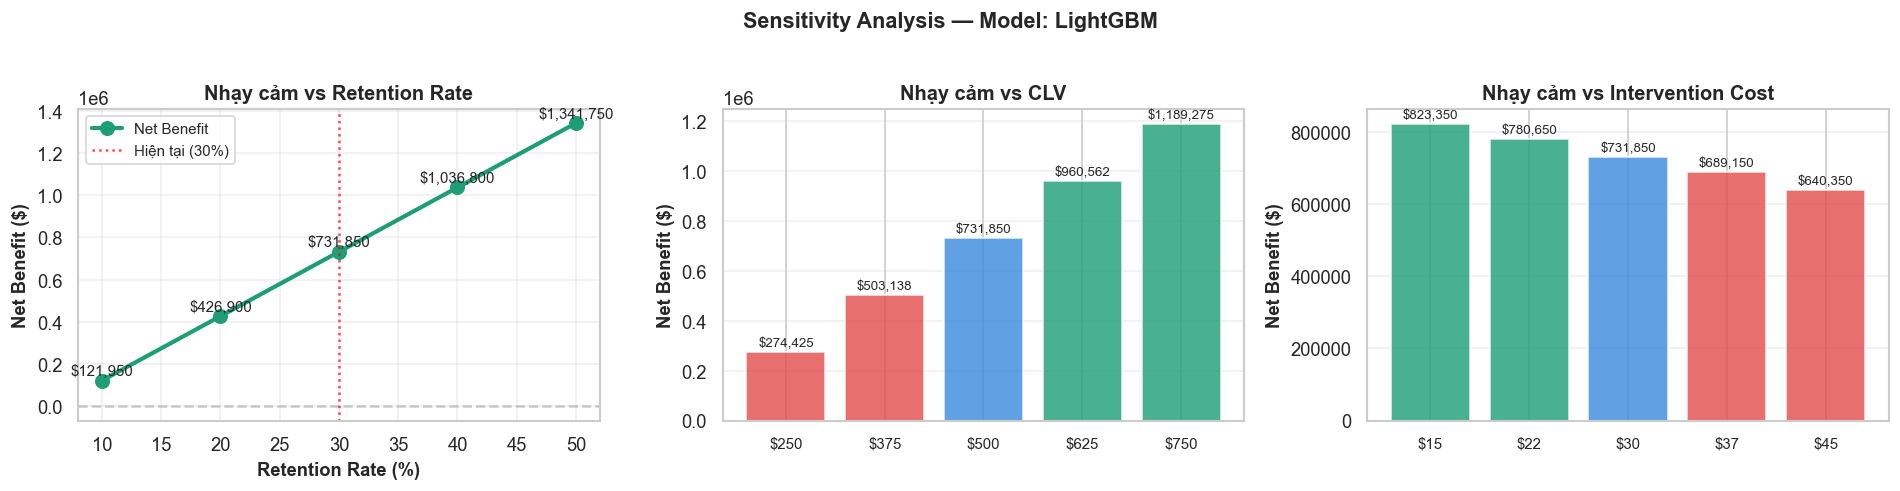


KẾT LUẬN SENSITIVITY ANALYSIS

✓ Retention Rate breakeven: 10% (dưới đó lỗ)
✓ Intervention Cost tối ưu: ≤ $15
✓ Net Benefit khi CLV cao nhất: $1,189,275

→ Khuyến nghị: Tập trung vào tăng Retention Rate (độ nhạy cao nhất)
   vì nó ảnh hưởng trực tiếp đến doanh thu từ can thiệp.

Tham số hiện tại: CLV=$500 | Can thiệp=$30/KH | Retention=30% | FN loss=50% CLV


In [45]:
# ════════════════════════════════════════════════════════════════════════════════
# Phân tích độ nhạy (Sensitivity Analysis) — tác động của thay đổi giả định kinh doanh
# ════════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SENSITIVITY ANALYSIS — Tác động của thay đổi tham số kinh doanh')
print('='*80 + '\n')

# Lấy best model từ business impact analysis
best_biz_model = max(biz, key=lambda n: biz[n]['net'])

# ── Thay đổi Retention Rate ───────────────────────────────────────────────────
print('1️⃣  RETENTION RATE (tỷ lệ giữ chân): {:.0f}% → thay đổi [10%, 20%, 30%, 40%, 50%]'.format(RETENTION_RATE*100))
print('─' * 80)

retention_rates = [0.10, 0.20, 0.30, 0.40, 0.50]
sensitivity_retention = {}

for ret_rate in retention_rates:
    tn, fp, fn, tp = cm_func(y_test, results[best_biz_model]['y_pred']).ravel()
    benefit  = tp * ret_rate * CLV
    cost     = (tp + fp) * COST_INTERVENTION
    fn_loss  = fn * CLV * FN_LOSS_RATE
    net      = benefit - cost - fn_loss
    vs_base  = net + baseline_loss
    sensitivity_retention[ret_rate] = net
    print(f'  Retention {ret_rate*100:>3.0f}% → Net Benefit: ${net:>10,.0f}  |  vs Baseline: ${vs_base:>10,.0f}')

# ── Thay đổi CLV ─────────────────────────────────────────────────────────────
print('\n2️⃣  CLV (Giá trị vòng đời khách): ${} → thay đổi [${}, ${}, ${}, ${}, ${}]'.format(
    CLV, int(CLV*0.5), int(CLV*0.75), CLV, int(CLV*1.25), int(CLV*1.5)))
print('─' * 80)

clv_values = [int(CLV*0.5), int(CLV*0.75), CLV, int(CLV*1.25), int(CLV*1.5)]
sensitivity_clv = {}

for clv_val in clv_values:
    tn, fp, fn, tp = cm_func(y_test, results[best_biz_model]['y_pred']).ravel()
    benefit           = tp * RETENTION_RATE * clv_val
    cost              = (tp + fp) * COST_INTERVENTION
    fn_loss           = fn * clv_val * FN_LOSS_RATE
    net               = benefit - cost - fn_loss
    baseline_loss_clv = int(y_test.sum()) * clv_val * FN_LOSS_RATE
    vs_base           = net + baseline_loss_clv
    sensitivity_clv[clv_val] = net
    print(f'  CLV ${clv_val:>5} → Net Benefit: ${net:>10,.0f}  |  vs Baseline: ${vs_base:>10,.0f}')

# ── Thay đổi Intervention Cost ───────────────────────────────────────────────
print('\n3️⃣  INTERVENTION COST (Chi phí can thiệp): ${} → thay đổi [${}, ${}, ${}, ${}, ${}]'.format(
    COST_INTERVENTION, int(COST_INTERVENTION*0.5), int(COST_INTERVENTION*0.75),
    COST_INTERVENTION, int(COST_INTERVENTION*1.25), int(COST_INTERVENTION*1.5)))
print('─' * 80)

cost_values = [int(COST_INTERVENTION*0.5), int(COST_INTERVENTION*0.75), COST_INTERVENTION,
               int(COST_INTERVENTION*1.25), int(COST_INTERVENTION*1.5)]
sensitivity_cost = {}

for cost_val in cost_values:
    tn, fp, fn, tp = cm_func(y_test, results[best_biz_model]['y_pred']).ravel()
    benefit  = tp * RETENTION_RATE * CLV
    cost     = (tp + fp) * cost_val
    fn_loss  = fn * CLV * FN_LOSS_RATE
    net      = benefit - cost - fn_loss
    vs_base  = net + baseline_loss
    sensitivity_cost[cost_val] = net
    print(f'  Cost ${cost_val:>3} → Net Benefit: ${net:>10,.0f}  |  vs Baseline: ${vs_base:>10,.0f}')

# ── Biểu đồ Sensitivity ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Subplot 1: Retention Rate
ax = axes[0]
ret_pcts   = [r*100 for r in retention_rates]
nets_ret   = list(sensitivity_retention.values())
offset_ret = max(abs(np.array(nets_ret)).max() * 0.02, 500)

ax.plot(ret_pcts, nets_ret, marker='o', linewidth=2.5, markersize=8,
        color='#1D9E75', label='Net Benefit')
ax.axhline(0, color='#999', linestyle='--', alpha=0.5)
ax.axvline(RETENTION_RATE*100, color='red', linestyle=':', alpha=0.7,
           label=f'Hiện tại ({RETENTION_RATE*100:.0f}%)')
ax.set_xlabel('Retention Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Net Benefit ($)', fontsize=11, fontweight='bold')
ax.set_title('Nhạy cảm vs Retention Rate', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
for x, y_val in zip(ret_pcts, nets_ret):
    ax.text(x, y_val + offset_ret, f'${y_val:,.0f}', ha='center', fontsize=9)

# Subplot 2: CLV
ax = axes[1]
clv_labels = [f'${int(c)}' for c in clv_values]
nets_clv   = list(sensitivity_clv.values())
offset_clv = max(abs(np.array(nets_clv)).max() * 0.02, 500)
clv_colors = ['#E24B4A' if c < CLV else '#378ADD' if c == CLV else '#1D9E75'
               for c in clv_values]

bars = ax.bar(range(len(clv_values)), nets_clv, color=clv_colors,
              alpha=0.8, edgecolor='white')
ax.axhline(0, color='#999', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(clv_values)))
ax.set_xticklabels(clv_labels, fontsize=9)
ax.set_ylabel('Net Benefit ($)', fontsize=11, fontweight='bold')
ax.set_title('Nhạy cảm vs CLV', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, y_val in enumerate(nets_clv):
    ax.text(i, y_val + offset_clv, f'${y_val:,.0f}', ha='center', fontsize=8)

# Subplot 3: Intervention Cost
ax = axes[2]
cost_labels = [f'${int(c)}' for c in cost_values]
nets_cost   = list(sensitivity_cost.values())
offset_cost = max(abs(np.array(nets_cost)).max() * 0.02, 500)
cost_colors = ['#1D9E75' if c < COST_INTERVENTION else '#378ADD' if c == COST_INTERVENTION else '#E24B4A'
               for c in cost_values]

bars = ax.bar(range(len(cost_values)), nets_cost, color=cost_colors,
              alpha=0.8, edgecolor='white')
ax.axhline(0, color='#999', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(cost_values)))
ax.set_xticklabels(cost_labels, fontsize=9)
ax.set_ylabel('Net Benefit ($)', fontsize=11, fontweight='bold')
ax.set_title('Nhạy cảm vs Intervention Cost', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, y_val in enumerate(nets_cost):
    ax.text(i, y_val + offset_cost, f'${y_val:,.0f}', ha='center', fontsize=8)

plt.suptitle(f'Sensitivity Analysis — Model: {best_biz_model}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Kết luận ─────────────────────────────────────────────────────────────────
print('\n' + '='*80)
print('KẾT LUẬN SENSITIVITY ANALYSIS')
print('='*80)

retention_for_break_even = [r for r, net in sensitivity_retention.items() if net >= 0]
if retention_for_break_even:
    print(f'\n✓ Retention Rate breakeven: {min(retention_for_break_even)*100:.0f}% (dưới đó lỗ)')
else:
    print(f'\n✗ Không đạt breakeven trong khoảng Retention Rate đã thử (10%–50%)')

cost_for_max_net = max(sensitivity_cost, key=sensitivity_cost.get)
print(f'✓ Intervention Cost tối ưu: ≤ ${cost_for_max_net}')

clv_max_net = max(sensitivity_clv.values())
print(f'✓ Net Benefit khi CLV cao nhất: ${clv_max_net:,.0f}')

print(f'\n→ Khuyến nghị: Tập trung vào tăng Retention Rate (độ nhạy cao nhất)')
print(f'   vì nó ảnh hưởng trực tiếp đến doanh thu từ can thiệp.')
print(f'\nTham số hiện tại: CLV=${CLV} | Can thiệp=${COST_INTERVENTION}/KH'
      f' | Retention={RETENTION_RATE*100:.0f}% | FN loss={FN_LOSS_RATE*100:.0f}% CLV')